In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import kge, mkge, nse, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_curve_number,
    jablje_groundwater,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
K_FOLDS = 5
N_REPEATS = 10
MAX_WORKERS = os.cpu_count()

ALL_YEARS = [y for y in range(1993, 2024) if y != 2017]
print(f"Total years: {len(ALL_YEARS)}  ({ALL_YEARS[0]}–{ALL_YEARS[-1]}, excluding 2017)")
print(f"Total folds to run: {K_FOLDS * N_REPEATS}")

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}
print(f"Observed biomass years: {sorted(observed_biomass['year'].tolist())}")

Total years: 30  (1993–2023, excluding 2017)
Total folds to run: 50
Observed biomass years: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023]


In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"cmaes_jablje_kfold_biomass_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
param_names = [
    #"harvest_index",
    "gdd_emergence",
    "gdd_max_rooting",
    "gdd_senescence",
    "gdd_maturity",
    #"gdd_flowering",
    #"gdd_flowering_length",
    #"gdd_hi_start",
    "max_canopy_cover",
    "cgc_gdd",
    "cdc_gdd",
    "ksat",
    "min_rooting_depth",
    "max_rooting_depth",
    "p_upper_senescence",
    "p_upper_stomata"
]

bounds = [
    #(0.46, 0.6),    # harvest_index
    (5, 40),        # gdd_emergence
    (700, 1000),    # gdd_max_rooting
    (700, 1000),    # gdd_senescence
    (900, 1200),    # gdd_maturity
    #(480,  530),    # gdd_flowering
    #(130,  170),    # gdd_flowering_length
    #(300, 500),     # gdd_hi_start
    (0.85, 0.97),   # max_canopy_cover
    (0.005, 0.03),  # cgc_gdd
    (0.005, 0.02),  # cdc_gdd
    (5, 1000),      # ksat
    (0.05, 0.4),    # min_rooting_depth
    (0.5, 2.5),     # max_rooting_depth
    (0.4, 0.8),     # p_upper_senescence
    (0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

def to_unit(x):
    return (np.asarray(x) - lower) / (upper - lower)

def from_unit(x_norm):
    return lower + np.asarray(x_norm) * (upper - lower)

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")

Parameters: ['gdd_emergence', 'gdd_max_rooting', 'gdd_senescence', 'gdd_maturity', 'max_canopy_cover', 'cgc_gdd', 'cdc_gdd', 'ksat', 'min_rooting_depth', 'max_rooting_depth', 'p_upper_senescence', 'p_upper_stomata']
x0:         [2.250e+01 8.500e+02 8.500e+02 1.050e+03 9.100e-01 1.750e-02 1.250e-02
 5.025e+02 2.250e-01 1.500e+00 6.000e-01 6.000e-01]


In [6]:
years_array = np.array(ALL_YEARS)

biomass_series = observed_biomass.set_index("year").loc[ALL_YEARS, "yield"]
biomass_bins = pd.qcut(biomass_series, q=K_FOLDS, labels=False).values

print("Biomass quantile bins per year:")
for y, b, bio in zip(ALL_YEARS, biomass_bins, biomass_series):
    print(f"  {y}: {bio:.2f} t/ha → bin {b}")

kf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=N_REPEATS, random_state=42)

folds = []
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(years_array, biomass_bins)):
    repeat  = fold_idx // K_FOLDS + 1
    split   = fold_idx  % K_FOLDS + 1
    train_years = years_array[train_idx].tolist()
    test_years  = years_array[test_idx].tolist()
    folds.append({"train": train_years, "test": test_years, "repeat": repeat, "split": split})

print(f"Total folds: {len(folds)}  ({N_REPEATS} repeats × {K_FOLDS} splits)")

Biomass quantile bins per year:
  1993: 18.93 t/ha → bin 2
  1994: 25.96 t/ha → bin 4
  1995: 25.45 t/ha → bin 4
  1996: 15.43 t/ha → bin 1
  1997: 18.41 t/ha → bin 2
  1998: 15.11 t/ha → bin 0
  1999: 20.10 t/ha → bin 3
  2000: 19.04 t/ha → bin 2
  2001: 13.83 t/ha → bin 0
  2002: 19.79 t/ha → bin 3
  2003: 15.38 t/ha → bin 1
  2004: 11.55 t/ha → bin 0
  2005: 21.96 t/ha → bin 4
  2006: 14.16 t/ha → bin 0
  2007: 21.96 t/ha → bin 4
  2008: 16.96 t/ha → bin 2
  2009: 8.08 t/ha → bin 0
  2010: 12.01 t/ha → bin 0
  2011: 17.53 t/ha → bin 2
  2012: 16.43 t/ha → bin 1
  2013: 19.30 t/ha → bin 3
  2014: 21.56 t/ha → bin 3
  2015: 15.39 t/ha → bin 1
  2016: 18.30 t/ha → bin 2
  2018: 16.57 t/ha → bin 1
  2019: 19.81 t/ha → bin 3
  2020: 26.65 t/ha → bin 4
  2021: 21.80 t/ha → bin 3
  2022: 15.31 t/ha → bin 1
  2023: 25.15 t/ha → bin 4
Total folds: 50  (10 repeats × 5 splits)


In [7]:
def make_simulation_periods(years):
    return [
        {
            "start_date": date(y, 1, 1),
            "end_date":   date(y, 12, 31),
            "planting_date": date(y, 5, 3),
            "is_seeding_year": True,
        }
        for y in years
    ]


def evaluate_params(param_values, sim_periods):
    """Run one candidate on the given simulation periods and return biomass metrics."""
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(jablje_maize_params)
        current_ksat = None

        for name, val in zip(param_names, param_values):
            if name == "ksat":
                current_ksat = float(val)
            else:
                crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es-kfold",
            params=crop_params,
        )

        if current_ksat is not None:
            modified_layers = copy.deepcopy(jablje_soil_layers)
            for layer in modified_layers:
                layer.ksat = current_ksat
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=modified_layers,
                curve_number=jablje_curve_number,
                readily_evaporable_water=jablje_readily_evaporable_water,
            )
        else:
            current_soil = soil

        simulation = AquaCrop(
            simulation_periods=sim_periods,
            crop=crop,
            soil=current_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_result = {"biomass_rmse": np.nan, "biomass_nse": np.nan, "biomass_kge": np.nan, "biomass_mkge": np.nan}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_result

        seasonal = results["season"][["Year1", "BioMass"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled"}
        )
        merged = observed_biomass.merge(seasonal, on="year")
        if merged.empty:
            return nan_result

        y_obs = merged["yield"].values
        y_mod = merged["biomass_modeled"].values
        return {
            "biomass_rmse": root_mean_squared_error(y_obs, y_mod),
            "biomass_nse":  nse(y_mod, y_obs),
            "biomass_kge":  kge(y_mod, y_obs),
            "biomass_mkge": mkge(y_mod, y_obs),
        }
    finally:
        dir_queue.put(working_dir)

In [8]:
SIGMA0 = 0.3
#default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = MAX_WORKERS #max(MAX_WORKERS, default_popsize)

x0_norm = to_unit(x0)  # all 0.5 — optimizer works in [0, 1]^n

CMAES_OPTIONS = {
    "bounds": [[0.0] * len(param_names), [1.0] * len(param_names)],
    "popsize": POPSIZE,
    "maxiter": 50, # based on loss function convergence run for one fold
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 43,
    "verbose": -9,   # suppress per-iteration output; fold progress printed manually
}

print(f"Cores: {MAX_WORKERS}  |  popsize: {POPSIZE}")

Cores: 28  |  popsize: 28


In [9]:
def run_fold(fold_idx, train_years, test_years, repeat, split):
    """Fit CMA-ES on train_years, evaluate on train and test. Returns a result dict."""
    train_periods = make_simulation_periods(train_years)
    test_periods  = make_simulation_periods(test_years)

    def objective(x_norm):
        r = evaluate_params(from_unit(x_norm), train_periods)
        return -r["biomass_mkge"] if np.isfinite(r["biomass_mkge"]) else 1e6

    def parallel_evaluate(solutions):
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            return list(executor.map(objective, solutions))

    es = cma.CMAEvolutionStrategy(x0_norm, SIGMA0, CMAES_OPTIONS)
    convergence = []
    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        convergence.append((es.result.iterations, es.result.fbest))

    xbest = from_unit(es.result.xbest)  # convert back to actual parameter values

    train_metrics = evaluate_params(xbest, train_periods)
    test_metrics  = evaluate_params(xbest, test_periods)

    total = K_FOLDS * N_REPEATS
    print(
        f"[{fold_idx+1}/{total}] repeat={repeat} split={split} — "
        f"train mkge={train_metrics['biomass_mkge']:.4f}  "
        f"test mkge={test_metrics['biomass_mkge']:.4f}  "
        f"(iters={es.result.iterations})"
    )

    return {
        "fold":        fold_idx + 1,
        "repeat":      repeat,
        "split":       split,
        "train_years": train_years,
        "test_years":  test_years,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}":  v for k, v in test_metrics.items()},
        **{f"best_{n}":  v for n, v in zip(param_names, xbest)},
        "iterations":  es.result.iterations,
        "evaluations": es.result.evaluations,
        "convergence": convergence,
    }

In [10]:
print(f"Running {N_REPEATS}×{K_FOLDS}-fold repeated stratified CV (objective: biomass mKGE) …")
fold_results = []
for fold_idx, fold in enumerate(folds):
    print(f"Fold {fold_idx+1}/{len(folds)}", flush=True)
    result = run_fold(fold_idx, fold["train"], fold["test"], fold["repeat"], fold["split"])
    fold_results.append(result)

print("\nAll folds complete.")

Running 10×5-fold repeated stratified CV (objective: biomass mKGE) …
AquaCrop simulation completed successfullyResults successfully parsed



In [11]:
import pickle

pickle.dump(fold_results, open(config.RESULTS_DIR / "cmaes_jablje_kfold.pkl", "wb"))
print(f"Saved {len(fold_results)} fold results to {config.RESULTS_DIR / 'cmaes_jablje_kfold.pkl'}")

In [12]:
results_df = pd.DataFrame(fold_results)

metric_cols = ["train_biomass_mkge", "train_biomass_nse", "train_biomass_rmse",
               "test_biomass_mkge",  "test_biomass_nse",  "test_biomass_rmse"]

# Per-repeat summary: mean metric across the 5 splits within each repeat
repeat_summary = results_df.groupby("repeat")[metric_cols].mean().round(4)
print(f"Per-repeat mean metrics ({K_FOLDS} splits averaged):")
display(repeat_summary)

means = results_df[metric_cols].mean()
stds  = results_df[metric_cols].std()
print(f"\nOverall mean ± std across all {len(results_df)} folds ({N_REPEATS} repeats × {K_FOLDS} splits):")
for col in metric_cols:
    print(f"  {col}: {means[col]:.4f} ± {stds[col]:.4f}")

,train_biomass_mkge,train_biomass_nse,train_biomass_rmse,test_biomass_mkge,test_biomass_nse,test_biomass_rmse
repeat,,,,,,
1,0.4728,-0.0543,4.4482,0.1931,-0.8402,5.4494
2,0.4848,-0.0635,4.4648,0.0837,-1.3202,5.9365
3,0.4717,-0.1370,4.6198,0.1738,-0.8231,5.4031
4,0.5070,-0.0782,4.4800,-0.1096,-1.7130,6.7138
5,0.5108,0.0244,4.1651,-0.1052,-1.8142,6.9149
6,0.4710,-0.1444,4.4576,0.1017,-0.3199,4.7755
7,0.4802,-0.0533,4.4290,0.0382,-1.4285,6.1870
8,0.4751,-0.1491,4.6501,-0.1846,-1.4206,6.3693
9,0.4707,-0.2493,4.7320,-0.0428,-1.5062,6.3246


C:\Users\rokku\AppData\Local\Temp\ipykernel_30796\3650994868.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


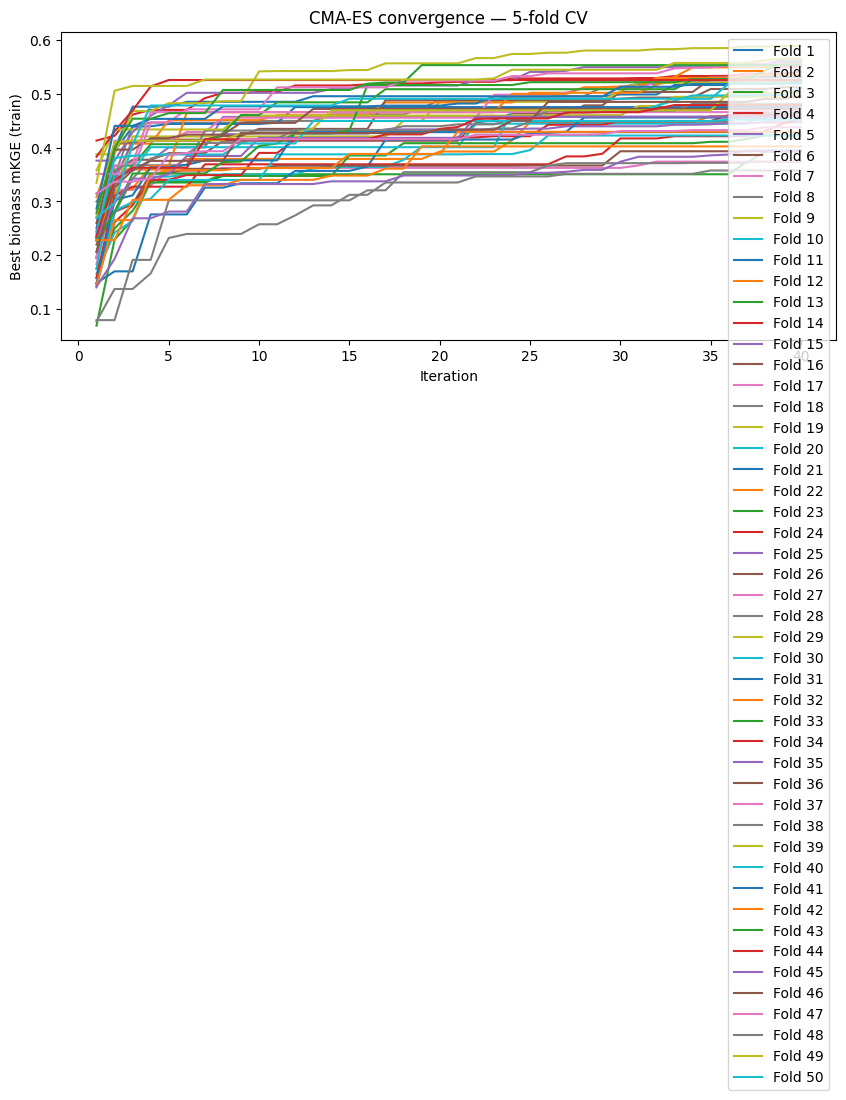

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

for result in fold_results:
    iters, fbest = zip(*result["convergence"])
    # fbest is -biomass_mkge (CMA-ES minimises), convert back to mKGE
    mkge_best = [-f for f in fbest]
    ax.plot(iters, mkge_best, label=f"Fold {result['fold']}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Best biomass mKGE (train)")
ax.set_title(f"CMA-ES convergence — {K_FOLDS}-fold CV")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
best_param_cols = [f"best_{n}" for n in param_names]
print("Best parameters per fold:")
display(results_df[best_param_cols].round(6))

print("\nMean best parameters:")
for col in best_param_cols:
    name = col.replace("best_", "")
    print(f"  {name}: {results_df[col].mean():.6f} ± {results_df[col].std():.6f}")

,best_gdd_emergence,best_gdd_max_rooting,best_gdd_senescence,best_gdd_maturity,best_max_canopy_cover,best_cgc_gdd,best_cdc_gdd,best_ksat,best_min_rooting_depth,best_max_rooting_depth,best_p_upper_senescence,best_p_upper_stomata
0,19.441815,876.747135,935.931262,1191.594170,0.925860,0.014408,0.006023,732.369058,0.074455,0.509509,0.731423,0.625086
1,30.032677,810.999097,995.883957,1197.583108,0.864003,0.014117,0.006652,768.861125,0.076537,0.512580,0.711730,0.633139
2,15.444106,755.072087,919.917331,1036.480862,0.891858,0.024074,0.006857,813.524490,0.050359,0.517777,0.556662,0.610221
3,34.656313,712.472356,997.365089,983.920220,0.923799,0.018699,0.020000,955.379859,0.343548,0.527265,0.692223,0.775761
4,21.291868,892.145129,944.518644,1165.841114,0.866850,0.013593,0.017346,776.310555,0.164305,0.685065,0.499077,0.667893
5,14.527078,702.422638,911.197283,1126.405559,0.873937,0.024676,0.019977,998.688059,0.070414,0.500757,0.651286,0.798193
6,12.915266,710.120097,994.094397,993.978844,0.892144,0.028656,0.018458,714.465180,0.184563,0.504859,0.539914,0.534301
7,39.265165,865.093293,997.112567,1199.121181,0.889972,0.014050,0.006238,610.306163,0.396217,0.538800,0.403193,0.413011
8,13.593715,700.019042,959.199757,1070.308792,0.851560,0.021087,0.007251,624.728483,0.070792,0.502710,0.617940,0.527630
9,18.840212,761.259257,926.419440,1117.169569,0.862689,0.014610,0.008291,870.731935,0.067015,0.501357,0.793052,0.595148


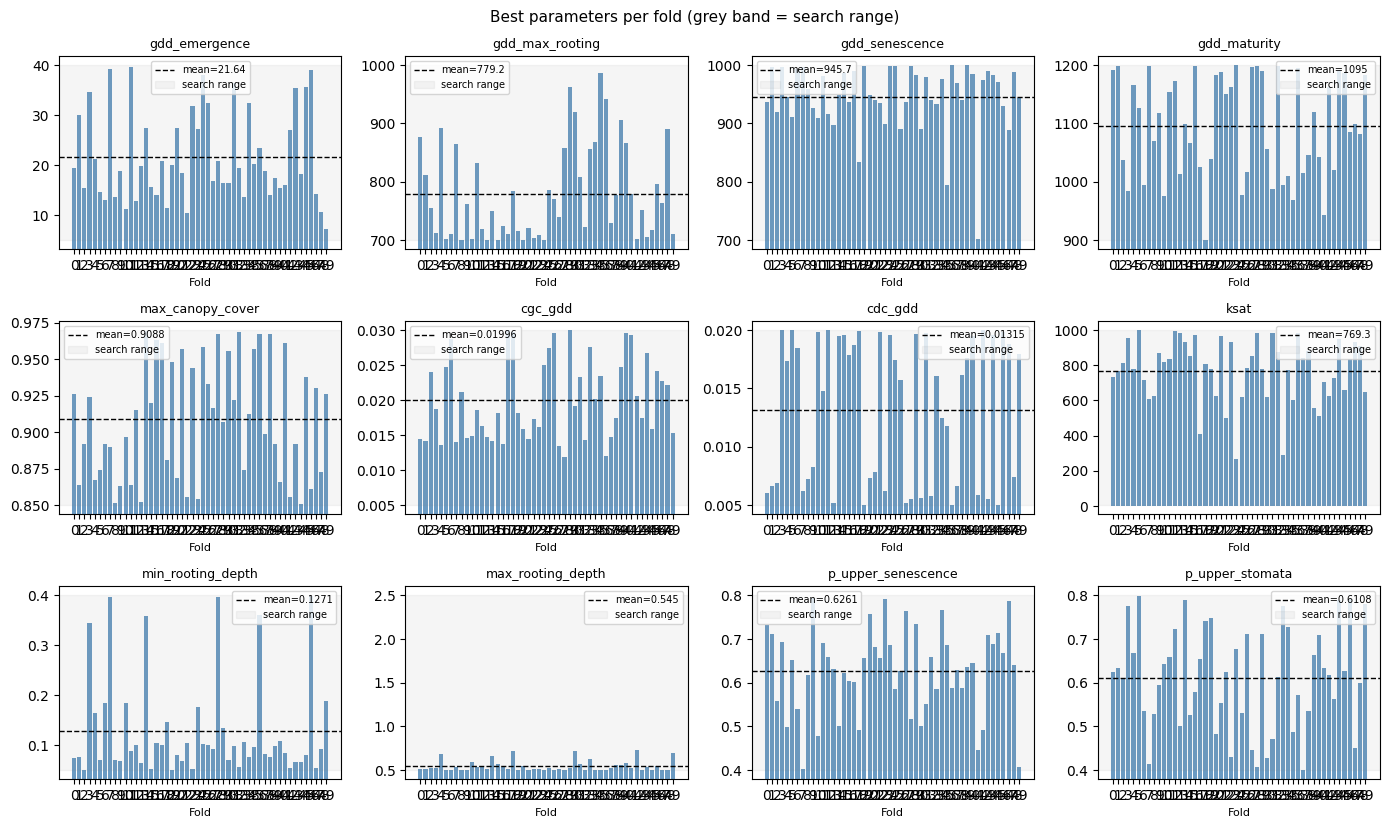

In [15]:
n_params = len(param_names)
ncols = 4
nrows = (n_params + ncols - 1) // ncols

bounds_dict = dict(zip(param_names, bounds))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
axes = axes.flatten()

for i, name in enumerate(param_names):
    col = f"best_{name}"
    vals = results_df[col]
    lo, hi = bounds_dict[name]

    ax = axes[i]
    ax.bar(results_df.index, vals, color="steelblue", alpha=0.8)
    ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.4g}")
    ax.axhspan(lo, hi, color="grey", alpha=0.08, label="search range")
    ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo))
    ax.set_title(name, fontsize=9)
    ax.set_xticks(results_df.index)
    ax.set_xlabel("Fold", fontsize=8)
    ax.legend(fontsize=7)

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Best parameters per fold (grey band = search range)", fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
best_param_cols = [f"best_{n}" for n in param_names]
param_stats = pd.DataFrame({
    "lower_bound":  [lo for lo, hi in bounds],
    "upper_bound":  [hi for lo, hi in bounds],
    "mean":   results_df[best_param_cols].mean().values,
    "median": results_df[best_param_cols].median().values,
    "std":    results_df[best_param_cols].std().values,
}, index=param_names)
display(param_stats.round(6))

,lower_bound,upper_bound,mean,median,std
gdd_emergence,5.000,40.00,21.642386,19.107677,9.009854
gdd_max_rooting,700.000,1000.00,779.191966,753.273198,81.455795
gdd_senescence,700.000,1000.00,945.748809,949.145600,56.853167
gdd_maturity,900.000,1200.00,1095.486687,1099.187156,87.436507
max_canopy_cover,0.850,0.97,0.908836,0.909691,0.040379
cgc_gdd,0.005,0.03,0.019959,0.018388,0.005740
cdc_gdd,0.005,0.02,0.013155,0.015869,0.006247
ksat,5.000,1000.00,769.307491,795.761937,180.526938
min_rooting_depth,0.050,0.40,0.127060,0.092354,0.099416
max_rooting_depth,0.500,2.50,0.544996,0.518542,0.063588


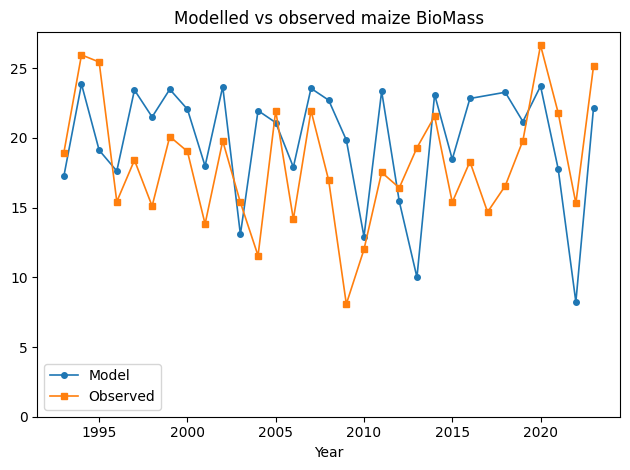

In [17]:
mean_params = param_stats["mean"].values

crop_params_avg = copy.deepcopy(jablje_maize_params)
avg_ksat = None
for name, val in zip(param_names, mean_params):
    if name == "ksat":
        avg_ksat = float(val)
    else:
        crop_params_avg[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if avg_ksat is not None:
    avg_layers = copy.deepcopy(jablje_soil_layers)
    for layer in avg_layers:
        layer.ksat = avg_ksat
    avg_soil = Soil(
        name=f"{LOCATION} soil",
        description="avg-params",
        soil_layers=avg_layers,
        curve_number=jablje_curve_number,
        readily_evaporable_water=jablje_readily_evaporable_water,
    )
else:
    avg_soil = soil

avg_dir = config.RAMDISK_DIR / "cmaes_jablje_kfold_avg"
avg_dir.mkdir(parents=True, exist_ok=True)

all_periods = make_simulation_periods(ALL_YEARS)
sim_avg = AquaCrop(
    simulation_periods=all_periods,
    crop=Crop(name=f"{LOCATION} maize", description="kfold-avg", params=crop_params_avg),
    soil=avg_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    working_dir=avg_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)
with contextlib.redirect_stdout(io.StringIO()):
    seasonal_avg = sim_avg.run()["season"]

plot_yield_timeseries_comparison(seasonal_avg, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

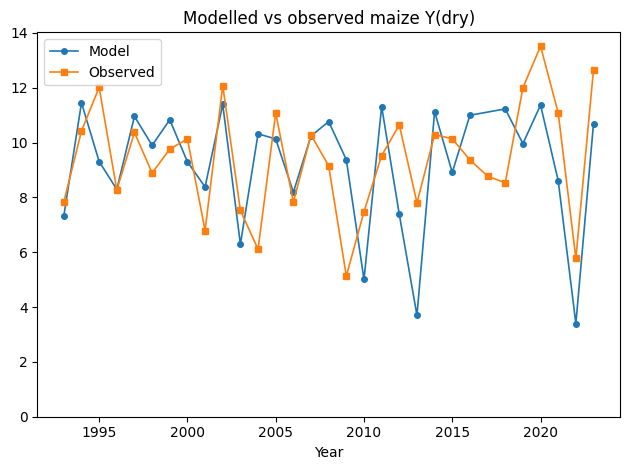

In [18]:
plot_yield_timeseries_comparison(seasonal_avg, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

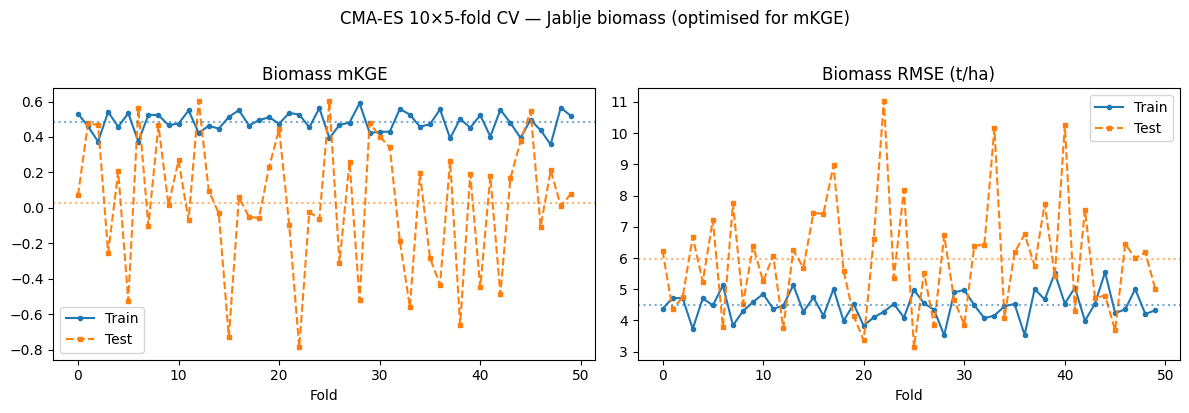

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "biomass_mkge", "Biomass mKGE"),
    (axes[1], "biomass_rmse", "Biomass RMSE (t/ha)"),
]:
    ax.plot(results_df.index, results_df[f"train_{metric}"], "o-", label="Train", markersize=3)
    ax.plot(results_df.index, results_df[f"test_{metric}"],  "s--", label="Test", markersize=3)
    ax.axhline(results_df[f"train_{metric}"].mean(), color="C0", linestyle=":", alpha=0.6)
    ax.axhline(results_df[f"test_{metric}"].mean(),  color="C1", linestyle=":", alpha=0.6)
    ax.set_xlabel("Fold")
    ax.set_title(title)
    ax.legend()

fig.suptitle(f"CMA-ES {N_REPEATS}×{K_FOLDS}-fold CV — Jablje biomass (optimised for mKGE)", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Re-run each fold's best params on its test years and collect predictions
all_predictions = []
for row in fold_results:
    xbest = [row[f"best_{n}"] for n in param_names]
    test_periods = make_simulation_periods(row["test_years"])

    crop_params = copy.deepcopy(jablje_maize_params)
    current_ksat = None
    for name, val in zip(param_names, xbest):
        if name == "ksat":
            current_ksat = float(val)
        else:
            crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    if current_ksat is not None:
        modified_layers = copy.deepcopy(jablje_soil_layers)
        for layer in modified_layers:
            layer.ksat = current_ksat
        current_soil = Soil(
            name=f"{LOCATION} soil",
            description="kfold-pred",
            soil_layers=modified_layers,
            curve_number=jablje_curve_number,
            readily_evaporable_water=jablje_readily_evaporable_water,
        )
    else:
        current_soil = soil

    pred_dir = config.RAMDISK_DIR / f"cmaes_jablje_kfold_pred_{row['fold']}"
    pred_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=test_periods,
        crop=Crop(name=f"{LOCATION} maize", description="kfold-pred", params=crop_params),
        soil=current_soil,
        management=jablje_optimal_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        working_dir=pred_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        seasonal = sim.run()["season"][["Year1", "BioMass"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled"}
        )
    seasonal["fold"] = row["fold"]
    all_predictions.append(seasonal)

pred_df = pd.concat(all_predictions).merge(observed_biomass, on="year")
print(f"Predictions assembled: {len(pred_df)} years")
pred_df

,year,biomass_modeled,fold,yield
0,1993,17.478,1,18.934
1,1994,15.632,1,25.962
2,1997,20.608,1,18.412
3,1998,5.553,1,15.111
4,2012,16.136,1,16.427
...,...,...,...,...
295,2001,17.188,50,13.830
296,2007,21.380,50,21.960
297,2013,10.571,50,19.301
298,2015,15.728,50,15.388


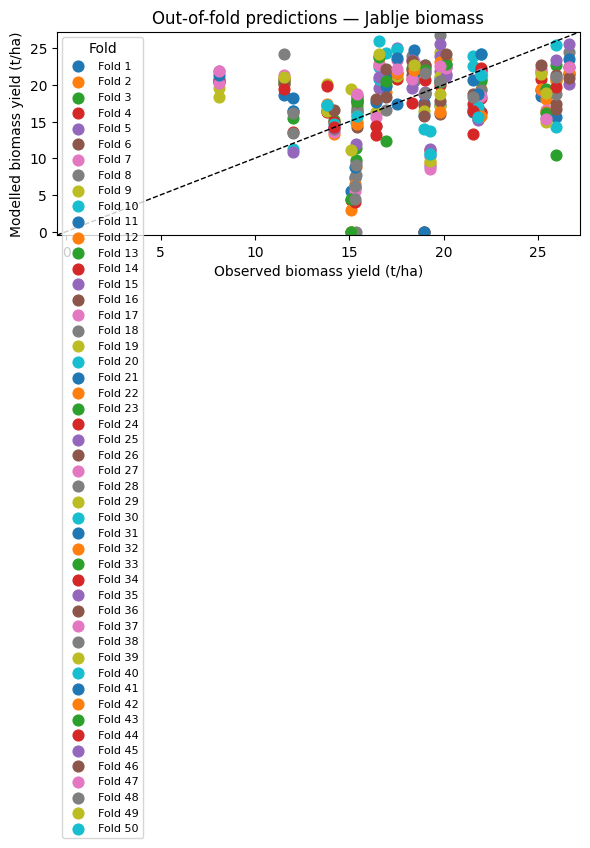

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

for fold_id, grp in pred_df.groupby("fold"):
    ax.scatter(grp["yield"], grp["biomass_modeled"], label=f"Fold {fold_id}", s=60)

lim = [pred_df[["yield", "biomass_modeled"]].min().min() - 0.5,
       pred_df[["yield", "biomass_modeled"]].max().max() + 0.5]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Observed biomass yield (t/ha)")
ax.set_ylabel("Modelled biomass yield (t/ha)")
ax.set_title("Out-of-fold predictions — Jablje biomass")
ax.legend(title="Fold", fontsize=8)
plt.tight_layout()
plt.show()

overall_mkge = mkge(pred_df["biomass_modeled"].values, pred_df["yield"].values)
overall_rmse = root_mean_squared_error(pred_df["yield"].values, pred_df["biomass_modeled"].values)
print(f"Overall out-of-fold mKGE: {overall_mkge:.4f}")
print(f"Overall out-of-fold RMSE: {overall_rmse:.4f} t/ha")